# Noise, Model Mismatch, and the Inverse Crime


## Discretization, Modeling, and the Inverse Crime

At this point in the course, students have seen that neural networks can learn reconstruction maps and that self-supervised strategies can use the forward operator directly inside the loss. This naturally raises a crucial question: how trustworthy are the data used for training and evaluation?

This is where the notion of the **inverse crime** enters, in the sense emphasized in the statistical inverse-problems literature {cite}`kaipio2005statistical`. It is one of the most important conceptual warnings in computational imaging. A method can appear extremely successful and still be tested in a mathematically unrealistic setting. If one does not explain this carefully, students may come away with the false impression that visually compelling reconstructions on synthetic data automatically imply physical reliability.

The purpose of this chapter is therefore twofold. First, we want to define precisely what the **inverse crime** is. Second, we want to understand why noise and **model mismatch** are not unpleasant implementation details, but central components of the inverse problem itself.


**The continuous world and the discrete world.**

The physical acquisition process takes place in a continuous world. Let $\mathcal{X}$ be a function space describing the unknown object and let

$$
\mathcal{A} : \mathcal{X} \to \mathcal{Y}
$$

be the true forward map. The actual measurements are then modeled as

$$
\boldsymbol{y}^\delta = \mathcal{A}(\boldsymbol{x}^\dagger) + \boldsymbol{e}_{\mathrm{phys}},
$$

where $\boldsymbol{x}^\dagger$ is the true object and $\boldsymbol{e}_{\mathrm{phys}}$ is the perturbation introduced by the acquisition device.

When we solve the problem on a computer, we cannot work directly with the infinite-dimensional object $\mathcal{A}$. We discretize both the image and the forward map and obtain a matrix model

$$
\boldsymbol{y}^\delta \approx K \boldsymbol{x} + \boldsymbol{e}.
$$

This passage from $\mathcal{A}$ to $K$ is unavoidable, but it is never exact. Discretization introduces approximation errors, interpolation effects, quadrature errors, geometric mismatch, and possible calibration inaccuracies.

This distinction between physical model and computational model is fundamental. A reconstruction algorithm never sees the true forward operator. It only sees its discrete surrogate.


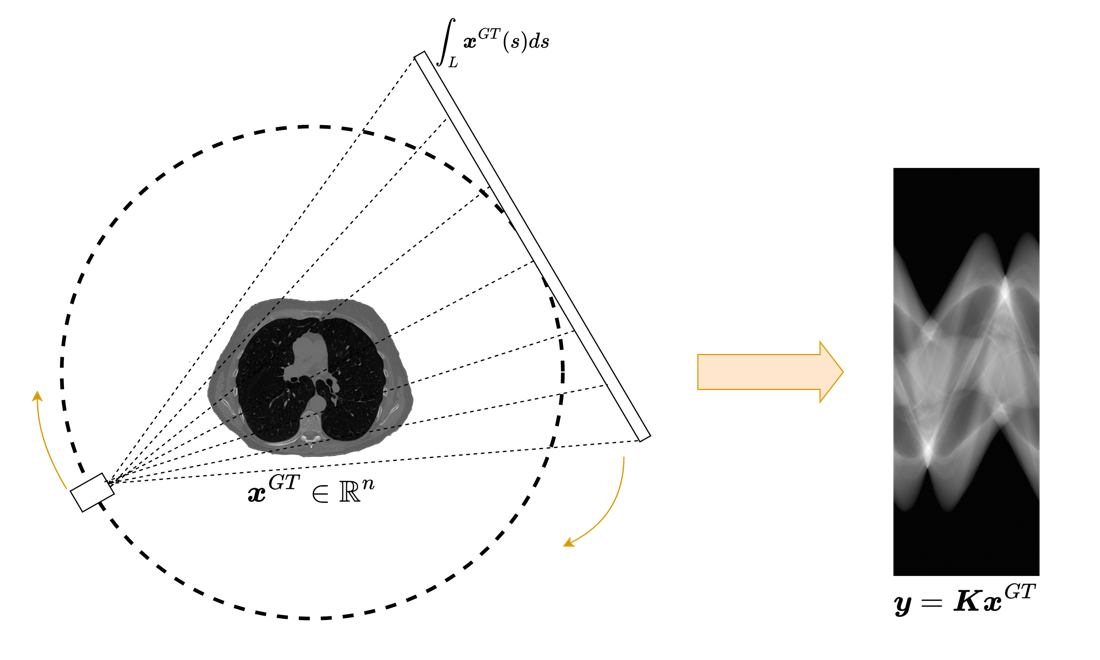

In [1]:
from pathlib import Path

def course_asset_path(name):
    here = Path.cwd().resolve()
    for base in (here, here.parent, here.parent.parent):
        candidate = base / 'imgs' / name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Could not locate imgs/{name} from {here}')
from PIL import Image
from IPython.display import display

display(Image.open(course_asset_path('CT_acquisition.png')).resize((1100, 660)))


```{warning}
A numerical model is never the physical system itself. Even when the formula looks similar, discretization, interpolation, detector geometry, and calibration conventions already change the effective forward operator seen by the algorithm.
```


**Definition of the inverse crime.**

The **inverse crime** occurs when synthetic data are generated using exactly the same discrete model that will later be used by the reconstruction algorithm. In the simplest case, one creates test data by choosing an image $\boldsymbol{x}^\dagger$ and setting

$$
\boldsymbol{y}_{\mathrm{syn}} = K \boldsymbol{x}^\dagger.
$$

Then one reconstructs using the same operator $K$.

At first sight this may seem perfectly reasonable. After all, if the goal is to test an inverse algorithm, why not test it on data generated by the model for which it was designed? The answer is that such a test is often too favorable. It removes the discrepancy between simulation and inversion that is inevitably present in real applications.

The crime becomes even worse when the synthetic measurements are noiseless or contain unrealistically simple perturbations. In that situation the inverse problem is made artificially benign, and the resulting performance estimates can be highly misleading.


**Error decomposition.**

To make the issue precise, suppose that data are generated by a richer simulation model $K_{\mathrm{sim}}$ acting on a finer representation of the object:

$$
\boldsymbol{y}^\delta = K_{\mathrm{sim}}\boldsymbol{x}^\dagger_{\mathrm{sim}} + \boldsymbol{e}.
$$

If reconstruction is then performed with a coarser model $K$, we may rewrite the measurement as

$$
\boldsymbol{y}^\delta
=
K \boldsymbol{x}^\dagger
+
\underbrace{(K_{\mathrm{sim}}\boldsymbol{x}^\dagger_{\mathrm{sim}} - K \boldsymbol{x}^\dagger)}_{\boldsymbol{e}_{\mathrm{model}}}
+
\boldsymbol{e}.
$$

The term $\boldsymbol{e}_{\mathrm{model}}$ is the model discrepancy. It accounts for everything that the inversion model fails to capture about the actual measurement process.

Now observe what happens if we generate the data with the same $K$ used for inversion. By construction,

$$
\boldsymbol{e}_{\mathrm{model}} = 0.
$$

In other words, one has removed one of the main sources of difficulty in the problem before the evaluation has even started.


In [2]:
import torch

torch.manual_seed(0)

n = 40
x = torch.linspace(0.0, 1.0, n)
x_true = torch.sin(2 * torch.pi * x) + 0.3 * torch.cos(5 * torch.pi * x)

A = torch.eye(n)
blur_kernel = torch.tensor([0.2, 0.6, 0.2])
A_sim = torch.zeros(n, n)
for i in range(n):
    for shift, value in enumerate(blur_kernel, start=-1):
        j = min(max(i + shift, 0), n - 1)
        A_sim[i, j] += value

noise = 0.02 * torch.randn(n)
y_exact = A @ x_true + noise
y_mismatch = A_sim @ x_true + noise

x_rec_exact = torch.linalg.lstsq(A, y_exact.unsqueeze(1)).solution.squeeze(1)
x_rec_mismatch = torch.linalg.lstsq(A, y_mismatch.unsqueeze(1)).solution.squeeze(1)

err_exact = torch.mean((x_rec_exact - x_true) ** 2).sqrt().item()
err_mismatch = torch.mean((x_rec_mismatch - x_true) ** 2).sqrt().item()

print(f'Reconstruction error with no model mismatch: {err_exact:.4f}')
print(f'Reconstruction error with model mismatch: {err_mismatch:.4f}')
print('The second experiment is still simple, but it is already less favorable.')


Reconstruction error with no model mismatch: 0.0191
Reconstruction error with model mismatch: 0.0189
The second experiment is still simple, but it is already less favorable.


## Noise Models, Spectral Effects, and Evaluation Risks

```{note}
Students often think of **noise** and **model mismatch** as two separate nuisances. In practice, they interact strongly: a reconstruction method that is fragile with respect to one is often fragile with respect to the other as well.
```

In classical inverse problems, the **inverse crime** is already problematic because it gives an overly optimistic picture of reconstruction stability. In deep learning, the danger is even greater because the network can quietly absorb all the artificial simplifications present in the training pipeline.

If training and test data are generated with the same simplified operator, the same discretization, the same boundary conventions, and the same simplified noise model, then the network may learn a reconstruction rule that works extremely well inside that synthetic universe while being very fragile outside it.

This is one of the reasons why deep learning papers in imaging must be read critically. Excellent numerical results are meaningful only if the data-generation protocol is realistic enough to challenge the model.


**The role of noise.**

The next point to explain carefully is that noise is not an annoying add-on. It is part of the inverse problem. The network is not trained to invert only the forward operator $K$, but to invert $K$ in the presence of perturbations.

Suppose that one trains with the objective

$$
\mathbb{E}\big[\|f_{\boldsymbol{\Theta}}(K\boldsymbol{x}+\boldsymbol{e})-\boldsymbol{x}\|^2\big].
$$

The distribution of $\boldsymbol{e}$ enters the training problem directly. Changing the noise model changes the optimization objective, and therefore changes the map that the network learns.

If one trains only on noiseless data, the learned reconstructor is encouraged to invert unstable directions of the forward model as aggressively as possible. But these are exactly the directions along which real measurements are most sensitive to perturbation.


**Singular value interpretation.**

Assume for simplicity that the operator admits an SVD

$$
K = U \Sigma V^T,
\qquad
\Sigma = \operatorname{diag}(\sigma_1,\dots,\sigma_r).
$$

In ill-posed problems, some **singular value**s are very small. Formal inversion amplifies the corresponding components by factors of order $1/\sigma_i$. Hence a small perturbation in the data may generate a large perturbation in the reconstruction.

This is the classical reason regularization is needed. Deep learning does not abolish this fact. If a network is trained on overly clean data, it may learn an unstable inverse map that behaves extremely well in synthetic experiments and very poorly on realistic measurements.

Thus, injecting realistic noise during training is not merely a way to make the task harder. It is a way to teach the network which directions in measurement space should be treated cautiously.


**Gaussian and **Poisson noise**.**

Two canonical models should be discussed explicitly.

**Additive **Gaussian noise**.**

Here one assumes

$$
\boldsymbol{e} \sim \mathcal{N}(0,\sigma^2 I),
\qquad
\boldsymbol{y}^\delta = K \boldsymbol{x}^\dagger + \boldsymbol{e}.
$$

This model is analytically convenient and often appropriate after certain preprocessing steps.

**Poisson noise.**

In photon-limited imaging, the measurements satisfy

$$
\boldsymbol{y}_j \sim \operatorname{Poisson}((K\boldsymbol{x}^\dagger)_j).
$$

Now the variance is signal-dependent. This changes the appropriate likelihood model and therefore changes the correct data-fidelity term. Treating such measurements as if they were corrupted by simple additive white **Gaussian noise** may be a severe modeling error.

This is a useful observation because it shows that the choice of noise model is mathematically tied to the likelihood. Once again, the statistical assumptions are part of the inverse problem itself.


In [3]:
import torch

torch.manual_seed(0)

signal = torch.full((5000,), 12.0)
gaussian = signal + 2.0 * torch.randn_like(signal)
poisson = torch.poisson(signal)

print('Gaussian sample mean and variance:')
print(float(gaussian.mean()), float(gaussian.var(unbiased=True)))
print('Poisson sample mean and variance:')
print(float(poisson.mean()), float(poisson.var(unbiased=True)))
print('For Poisson data, mean and variance are of comparable size.')


Gaussian sample mean and variance:
11.984770774841309 3.9322004318237305
Poisson sample mean and variance:
12.030200004577637 11.990885734558105
For Poisson data, mean and variance are of comparable size.


**The inverse crime in practice.**

The **inverse crime** can occur in many concrete forms:

- generating data with the same discrete operator used at reconstruction time;
- using exactly the same geometry, detector calibration, and boundary conventions in simulation and inversion;
- training and testing on synthetic samples created with the same simplistic random pipeline;
- ignoring structured or signal-dependent noise and replacing it by easy Gaussian perturbations;
- evaluating only on samples drawn from the same narrow distribution as the training images.

A good lecture should make clear that the crime is not a single technical mistake. It is a general attitude: evaluating a method in conditions that are unrealistically favorable to the reconstruction model.


**How to avoid the crime.**

There is no universal recipe, but a number of practical principles are widely useful.

1. Simulate with a model richer than the inversion model.
2. Use finer grids during data generation, then downsample.
3. Include realistic detector effects, blur, interpolation, and calibration errors when possible.
4. Use a physically plausible noise model.
5. Separate training, validation, and testing pipelines carefully.
6. Evaluate robustness under small but meaningful operator mismatch.

These points are good not only for research. They are good scientific hygiene in general.


**Consequences for teaching and evaluation.**

Students should be encouraged to ask the following questions whenever they see reconstruction results:

- how were the data generated;
- is the forward operator used for simulation the same as the one used for inversion;
- what noise model was assumed;
- are the test images truly out of sample;
- does the method remain stable under modest perturbations of the acquisition model.

If these questions are not answered, high PSNR and visually appealing outputs should not be accepted uncritically.


## Summary

This chapter should leave a strong and clear message:

- the true forward model and the discrete inversion model are not the same object;
- the **inverse crime** consists in testing under unrealistically compatible modeling assumptions;
- model discrepancy is part of the real problem;
- noise affects both the difficulty of inversion and the network learned during training;
- trustworthy computational imaging requires mismatch-aware simulation, training, and evaluation.


## Exercises

1. Define the **inverse crime** in your own words and explain why it leads to overly optimistic conclusions.
2. Give one example of model discrepancy in an imaging system.
3. Compare additive **Gaussian noise** and **Poisson noise** from the viewpoint of the likelihood model.
4. Explain why a network trained only on noiseless data may behave unstably in practice.


## Further Reading

This chapter should be revisited repeatedly during the course, because almost every modern reconstruction method can be made to look better than it really is through unrealistic simulation choices. A productive reading strategy is to take any numerical experiment and ask which parts of the pipeline are shared between simulation and inversion, which perturbations are modeled, and which are silently ignored.

For students interested in the broader theory, this topic connects naturally with model discrepancy, uncertainty quantification, and robust inverse problems.
